# Importing Required Packages

In [1]:
from sklearn.datasets import fetch_california_housing
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor

#Data Loading

In [2]:
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Combine feature names and target names for column headers
all_column_names = housing.feature_names + housing.target_names

# Combine feature data (X) and target data (y)
# np.c_ stacks arrays column-wise
combined_data = np.c_[housing.data, housing.target]

# Create the DataFrame
CHD_df = pd.DataFrame(combined_data, columns=all_column_names)

# Display the first few rows of the DataFrame
CHD_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Problem 2:


## (a) Exploratory Data Analysis (EDA)

### Descriptive Statistics
We computed summary statistics using:
`describe` Function

In [3]:
## descriptive Statistics
CHD_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


#### Results & Interpretation
- **Different scales**  
  Some features are on very different scales (like population vs income).  
  We should be careful when comparing them.

- **Mean vs Median**  
  For most features, the mean and median are close.  
  This means the data is not heavily skewed.

- **Variability**  
  Standard deviation shows how spread out the data is.  
  Some features vary more than others.

- **Outliers**  
  Features like AveRooms and Population have very large ranges.  
  This suggests possible outliers to check.

### Outliers Analysis and Interprete results
Boxplots were generated for selected features (`AveRooms`, `AveBedrms`).

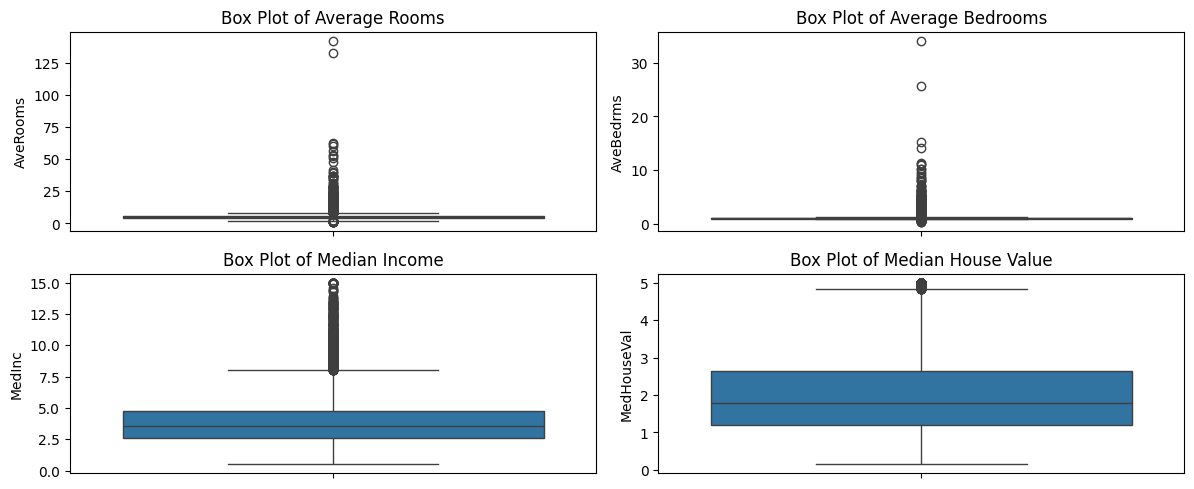

In [4]:
#create  box plot for AveRooms  and AveBedrms
plt.figure(figsize=(12, 5))

plt.subplot(2, 2, 1)
sns.boxplot(y='AveRooms', data=CHD_df)
plt.title('Box Plot of Average Rooms')

plt.subplot(2, 2, 2)
sns.boxplot(y='AveBedrms', data=CHD_df)
plt.title('Box Plot of Average Bedrooms')

plt.subplot(2, 2, 3)
sns.boxplot(y='MedInc', data=CHD_df)
plt.title('Box Plot of Median Income')

plt.subplot(2, 2, 4)
sns.boxplot(y='MedHouseVal', data=CHD_df)
plt.title('Box Plot of Median House Value')

plt.tight_layout()
plt.show()

#### Results & Interpretation

- **Visible outliers**  
  Outliers are present in both features.  
  Some values lie far beyond the interquartile range.

#### Key Insight

- Outliers can affect parameter estimation in **Maximum Likelihood Estimation (MLE)**.  
- Gaussian models are sensitive to extreme values, so results may be distorted.

#### Implication for MLE

- Outliers mean the **Gaussian noise assumption** may not fully hold.  
- Since outliers are few, MLE can still work reasonably well.


### Correlation Analysis (Heatmap)

In [5]:
corr_mat = CHD_df.corr()
corr_mat

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


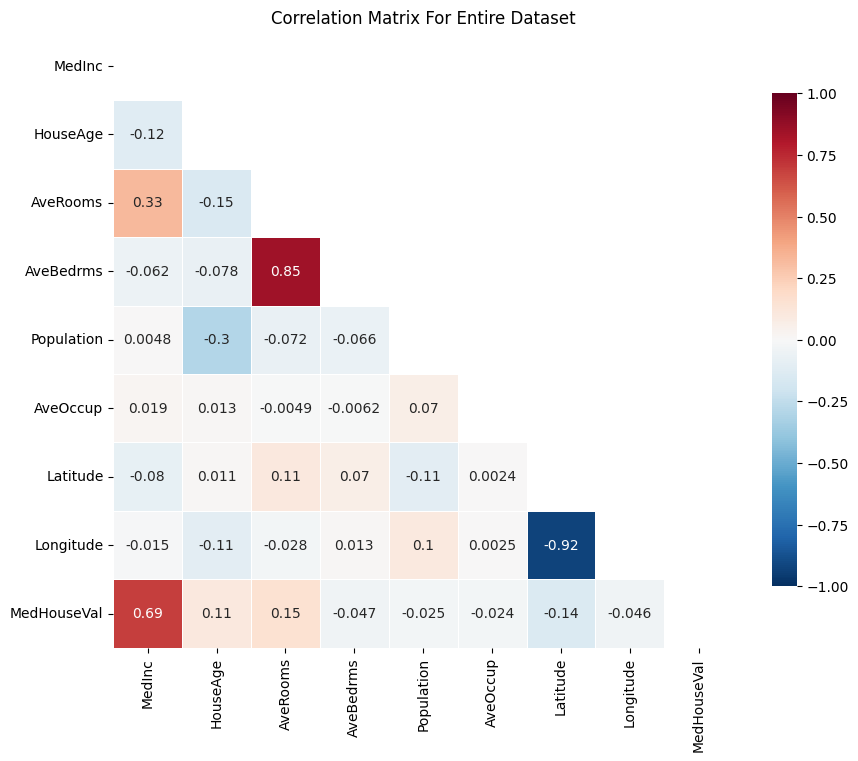

In [6]:
plt.figure(figsize=(10,8))
# plt.style.use('ggplot')
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, cmap='RdBu_r', vmin=-1, vmax=1,
            annot=True, linewidths=.5, cbar_kws={'shrink':.8})
plt.title('Correlation Matrix For Entire Dataset')
plt.show()

#### Results & Interpretation

- **Moderate correlation**  
  Some features show moderate correlation with the target (**MedHouseVal**).

- **Feature correlations**  
  There are also correlations between input features.  
  This means **multicollinearity** is present.


#### Key Insight

- High correlation between features = **multicollinearity**.  
- It does not break Gaussian assumptions directly, but it matters for estimation.

#### Implication for MLE
- Multicollinearity can make parameter estimates **unstable**.  
- It increases the **variance** of estimated coefficients.  
- Models may still work, but results should be interpreted with care.


### Distribution of Target Variable

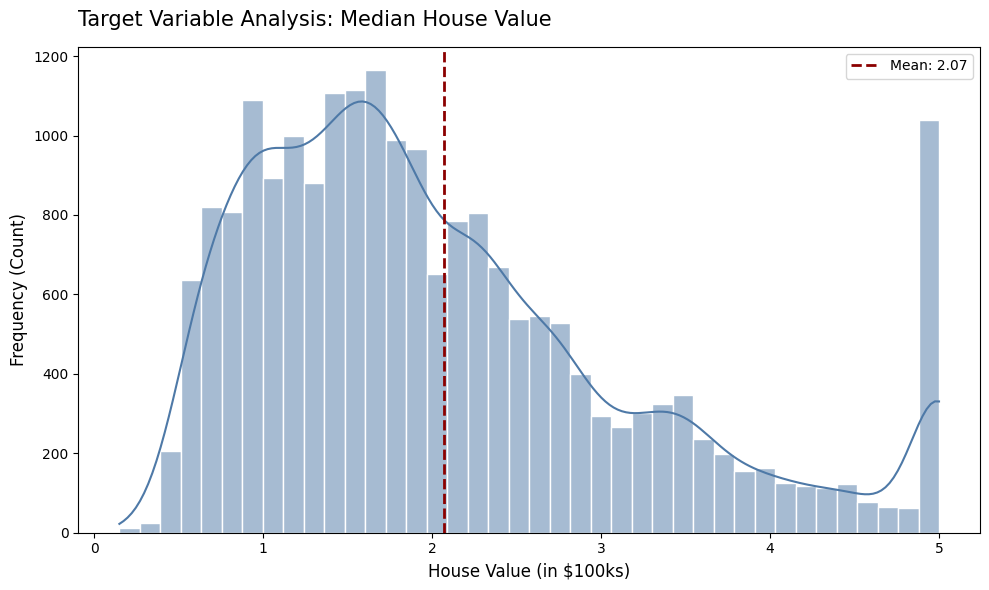

In [7]:
# 1. Visualization Setup
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-muted') # Modern, clean aesthetic

# 2. Draw Distribution
# Using 'bins' for granularity and changing color for a custom feel
target_plot = sns.histplot(x='MedHouseVal', data=CHD_df, kde=True,
                           color='#4e79a7', edgecolor='white', bins=40)

# 3. Add Statistical Context
# Highlighting the average house value with a vertical line
avg_val = CHD_df['MedHouseVal'].mean()
plt.axvline(avg_val, color='darkred', linestyle='--', linewidth=2, label=f'Mean: {avg_val:.2f}')

# 4. Refine Labels & Title
plt.title('Target Variable Analysis: Median House Value', fontsize=15, loc='left', pad=15)
plt.xlabel('House Value (in $100ks)', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()


#### Results & Interpretation

- **Bell-shaped distribution**  
  The data looks roughly bell-shaped, but with slight skewness.

- **Clustering**  
  Most values are near the center, with fewer extreme values.

#### Implication for MLE
- This supports the assumption of **Gaussian-distributed noise**.  
- A little skewness is acceptable in practice and usually does not cause problems.


### Feature vs Target (Scatter Plots)
Scatter plots were generated for each feature against the target.

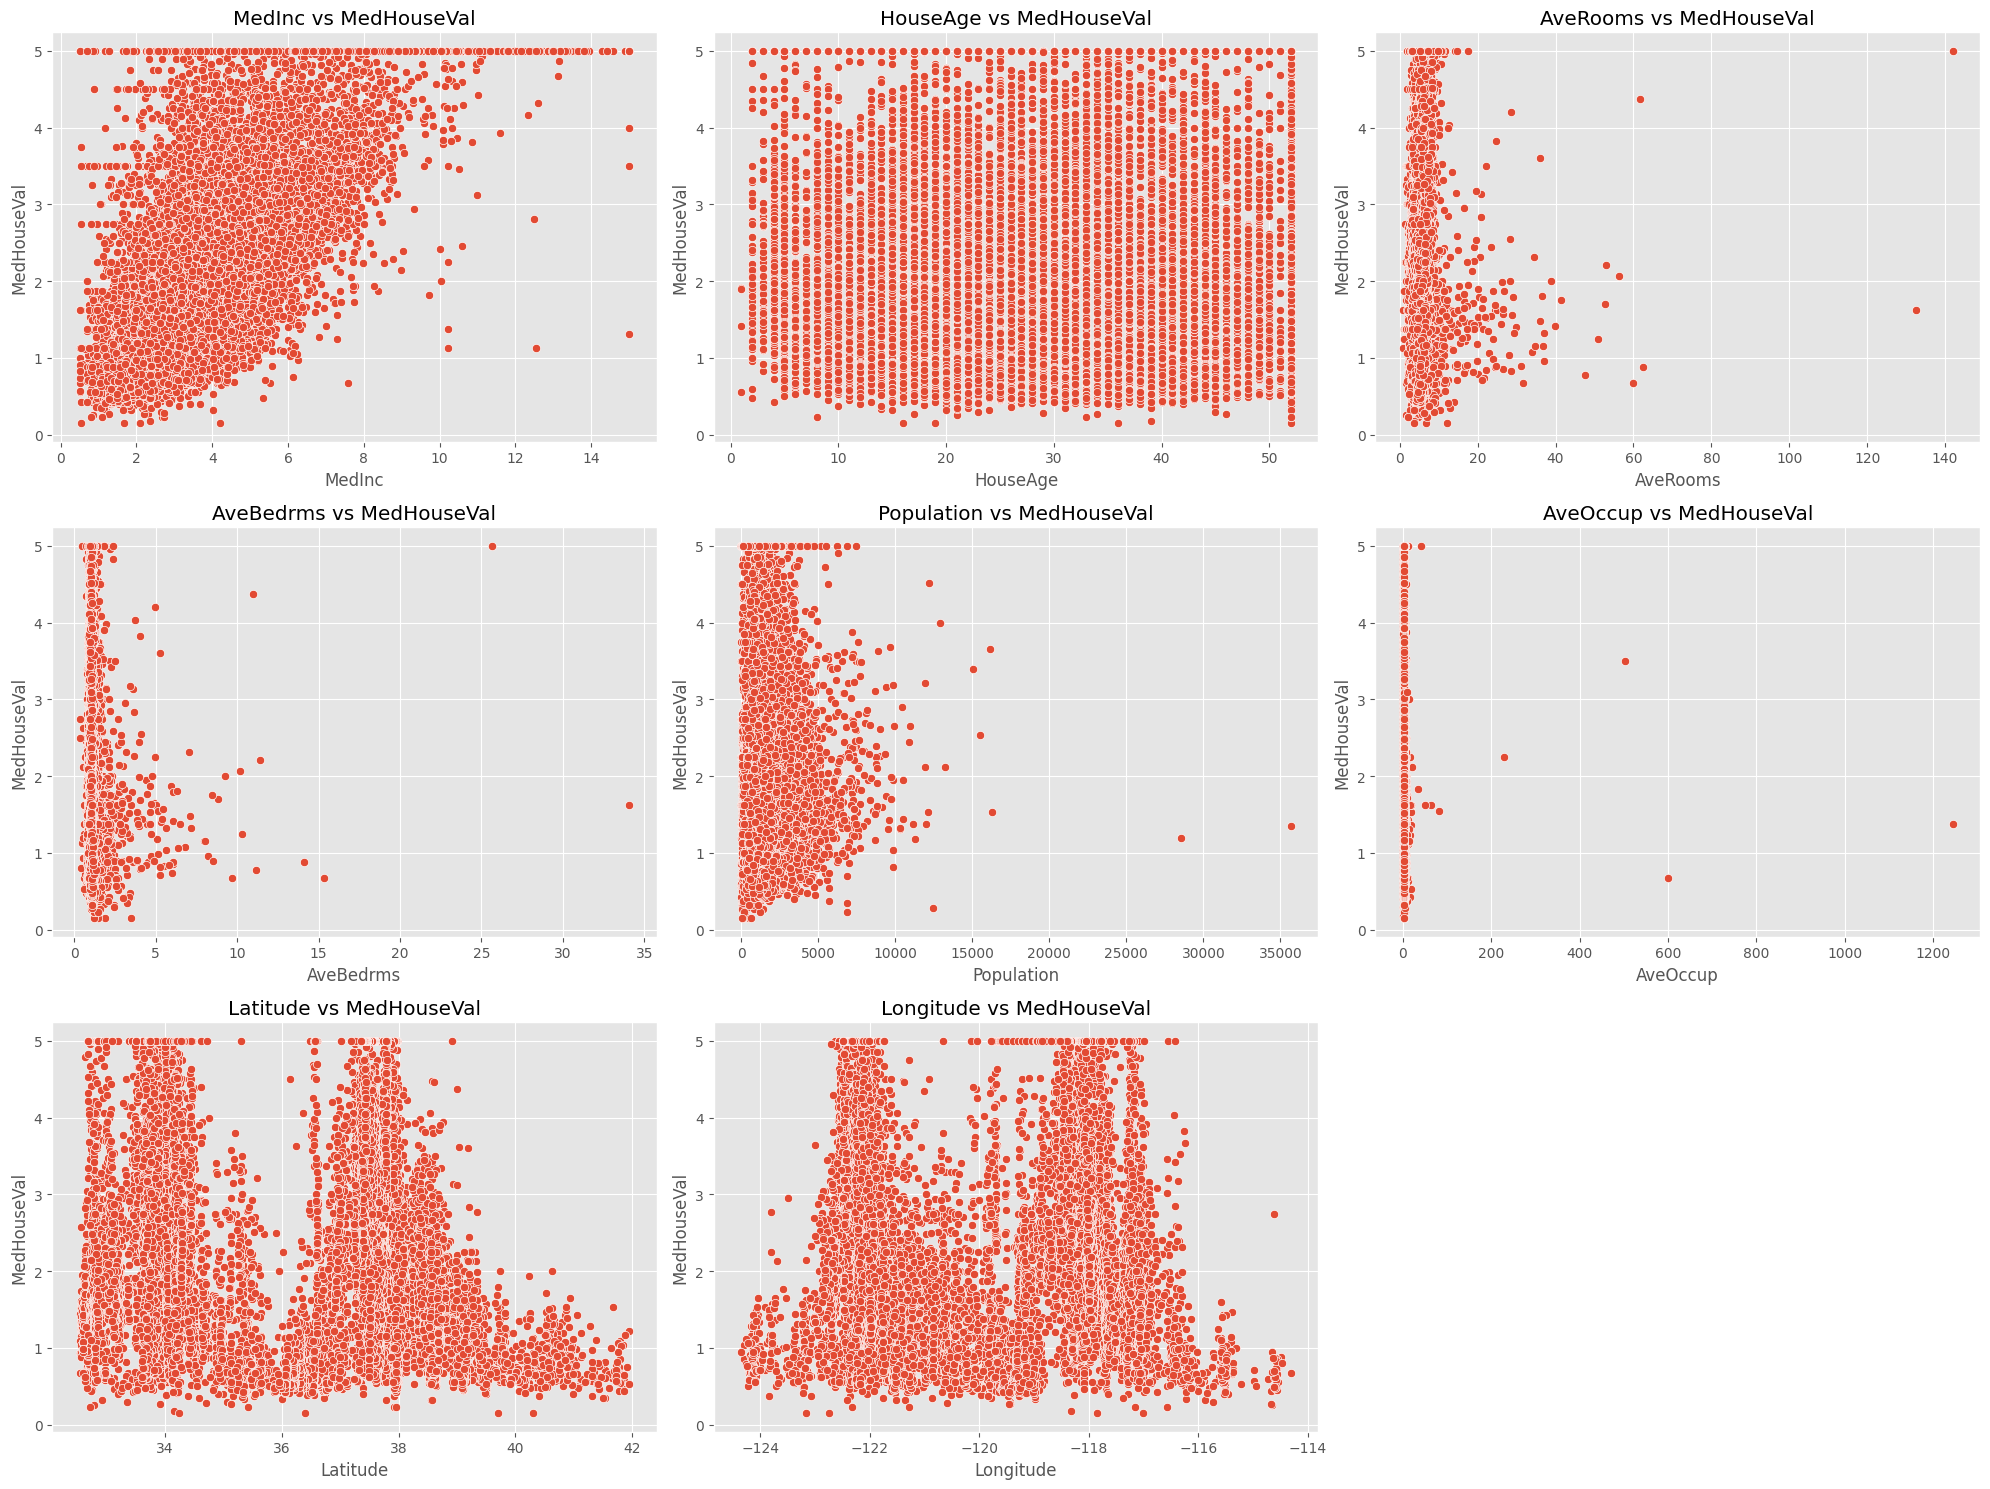

In [8]:
feature_cols = [col for col in CHD_df.columns if col != 'MedHouseVal']

n_cols = 3
n_rows = (len(feature_cols) + n_cols - 1) // n_cols # Calculate number of rows needed

plt.style.use('ggplot')
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

y = CHD_df['MedHouseVal']

for i, col in enumerate(feature_cols):
    sns.scatterplot(x=CHD_df[col], y=y, ax=axes[i])
    axes[i].set_title(f'{col} vs MedHouseVal')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('MedHouseVal')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Results & Interpretation

- **Linear trend**  
  Some features (like income-related ones) show a clear linear trend with the target (**MedHouseVal**).

- **Weaker relationships**  
  Other features show weaker or more scattered patterns.

- **Data distribution**  
  Points are spread around an imaginary straight line, showing both trend and noise.

#### Implication for MLE

- Supports the assumption of a **linear relationship** between features and the target.  
- The random spread around the line suggests **noise is present**, which is expected in practice.


## b) Normal Equation and Computational Complexity

The Normal Equation provides the closed‑form solution for the weights that minimize SSE (and thus maximize the log‑likelihood under Gaussian noise):

In [9]:
X = CHD_df.drop('MedHouseVal', axis=1)
y = CHD_df['MedHouseVal']

# Add bias
X_np = np.c_[np.ones(X.shape[0]), X.values]

# Normal equation
w = np.linalg.inv(X_np.T @ X_np) @ X_np.T @ y.values

# Get feature names and add 'Bias' for the intercept term
feature_names = ['Bias'] + X.columns.tolist()

# Set display option for float format
pd.set_option('display.float_format', '{:.6f}'.format)

# Display weights with feature names for better readability
normal_weights_df = pd.Series(w, index=feature_names)
print('Normal Equation Weights:')
print(normal_weights_df)

Normal Equation Weights:
Bias         -36.941920
MedInc         0.436693
HouseAge       0.009436
AveRooms      -0.107322
AveBedrms      0.645066
Population    -0.000004
AveOccup      -0.003787
Latitude      -0.421314
Longitude     -0.434514
dtype: float64


### Complexity Breakdown
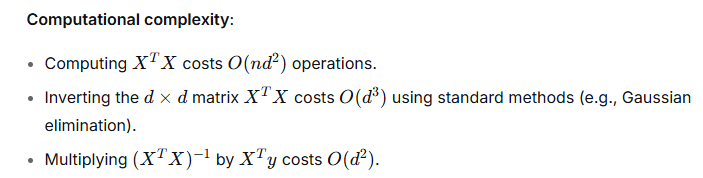

Thus the overall complexity is $O(nd^2 + d^3)$ For a large number of features d, the cubic term dominates, making the normal equation impractical.

#Problem 3
estimating w by minimizing the Negative Log-Likelihood


## (a) Negative Log‑Likelihood Function
From Problem 1, the log‑likelihood (ignoring constants that do not depend on w) is
\begin{equation}
\ell(w) = -\frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - w^T x_i)^2 + \text{const.}
\end{equation}

Thus the negative log‑likelihood (NLL) to be minimized is


\begin{equation}
J(w) = -\ell(w) = \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - w^T x_i)^2 + \text{const.}
\end{equation}


For optimization, the constant factor
$\frac{1}{\sigma^2}$ can be absorbed into the learning rate,

so we define
 \begin{equation}
\mathrm{gaussian\_nll}(w, X, y) = \frac{1}{2} \sum_{i=1}^{n} (y_i - w^T x_i)^2
\end{equation}

or equivalently, $\frac{1}{2} \| y - X w \|^2$

In [10]:
## Gausian NLL Function definition.
## loss function We use As our data comes from a Gaussian (Normal) distribution.
# Assumes Gaussian noise with sigma^2 = 1
# Equivalent to minimizing MSE

def gaussian_nll(w, X, y):
    return 0.5 * np.sum((y - X @ w)**2)

In [11]:
def model_gradient(features, targets, weights):
    """
    Computes the partial derivatives of the cost function
    with respect to the model parameters.
    """
    num_samples = targets.shape[0]

    # Calculate the residual (error) between predictions and actual values
    prediction_error = (features @ weights) - targets

    # Return the average gradient across all observations
    return (1 / num_samples) * (features.T @ prediction_error)


## (b) Gradient of the Log‑Likelihood
We computed the gradient of ℓ(w) with respect to w.

$\ell(w) = - \frac{1}{2\sigma^2} (y - X w)^T (y - X w)$ using matrix calculus



\begin{equation}
[
\nabla_w \ell(w) = - \frac{1}{2\sigma^2} \cdot 2 X^T (X w - y) = \frac{1}{\sigma^2} X^T (y - X w)
]
\end{equation}



Therefore, the gradient of the NLL, $J(w) = -\ell(w)$ is \begin{equation}
\quad \nabla_w J(w) = - \nabla_w \ell(w) = - \frac{1}{\sigma^2} X^T (y - X w) = \frac{1}{\sigma^2} X^T (X w - y)
\end{equation}


## (c) Gradient Descent Implementation
Below is the Implementation of Gradient Descent to minimize the Negative Log-Likelihood and update w over 1000 iterations.

In [12]:
def train_linear_model(features, target, learning_rate=1e-11, epochs=1000):
    """
    Optimizes weights using standard Gradient Descent to minimize Gaussian NLL.
    """
    # Initialize parameters
    n_samples, n_features = features.shape
    beta = np.zeros(n_features)
    history = []


    for _ in range(epochs):
        # Calculate Gradient and update weights
        gradient = model_gradient(features,target,beta)
        beta -= learning_rate * gradient

        # Track performance
        current_loss = gaussian_nll(beta, features, target)
        history.append(current_loss)

    return beta, history

optimized_beta, nll_history = train_linear_model(X_np, y.values, learning_rate=1e-8)

# Map results to features
labels = ['Bias'] + list(X.columns)
gradient_descent_weights_df = pd.Series(optimized_beta, index=labels)

print("Model Parameters:")
print(gradient_descent_weights_df)
print(f"\nOptimization converged at NLL: {nll_history[-1]:.6f}")

Model Parameters:
Bias          0.000008
MedInc        0.000047
HouseAge      0.000285
AveRooms      0.000051
AveBedrms     0.000009
Population    0.000823
AveOccup      0.000016
Latitude      0.000291
Longitude    -0.000985
dtype: float64

Optimization converged at NLL: 29154.604540


## d) Plot of the Negative Log-Likelihood value over each iteration

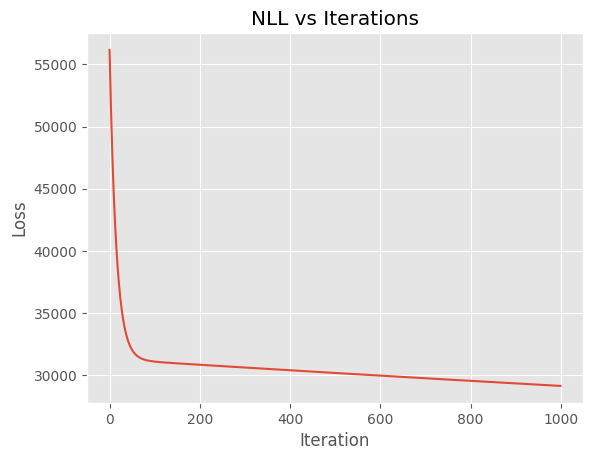

In [13]:
plt.plot(nll_history)
plt.style.use('ggplot')
plt.title("NLL vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

### Interpretation Of Results  

With Higher Values of Learning Rate, All results were **NaN (Not a Number)**, and warnings like *overflow encountered*.  

Simply Means, Our **Gradient Descent did not work properly**. Instead of moving toward a solution, the updates became too large, the values exploded, and ended up as `NaN`.

**Our Hypothesis And Reasons:**  
- The **learning rate is too high**(0.01), so the steps are too big and keep overshooting.  
- The **features are on different scales**, making the updates unstable and values became too large, causing overflow.

To Fix It We can Try To:

1. **Reduce the learning rate**  
   Use smaller values like `1e-7` or `1e-8`.  

2. **Scale features**  
   Normalize or standardize data so all features are on a similar range.

3.  **Increase Number of Iterations (epoch)**

#### Conclusion:
Curve is convex (parabolic shape)

Smooth monotonic decrease

Convergence rate: linear(Depending on Choosen Learning Rate).

#### Why convexity is desired in MLE
Convexity guarantees any local minimum is global for MLE this ensures the optimizer finds the global maximizer of the likelihood (or minimizer of NLL).

This removes concerns about multiple local optima and makes optimization robust and predictable.

### Trying Different Learning Rates

Optimization converged at NLL: 18441.603498
Optimization converged at NLL: 29154.604540
Optimization converged at NLL: 31116.309219
Optimization converged at NLL: 44962.204168
Optimization converged at NLL: 56187.484401
Optimization converged at NLL: 57723.756325
Optimization converged at NLL: 57882.490846


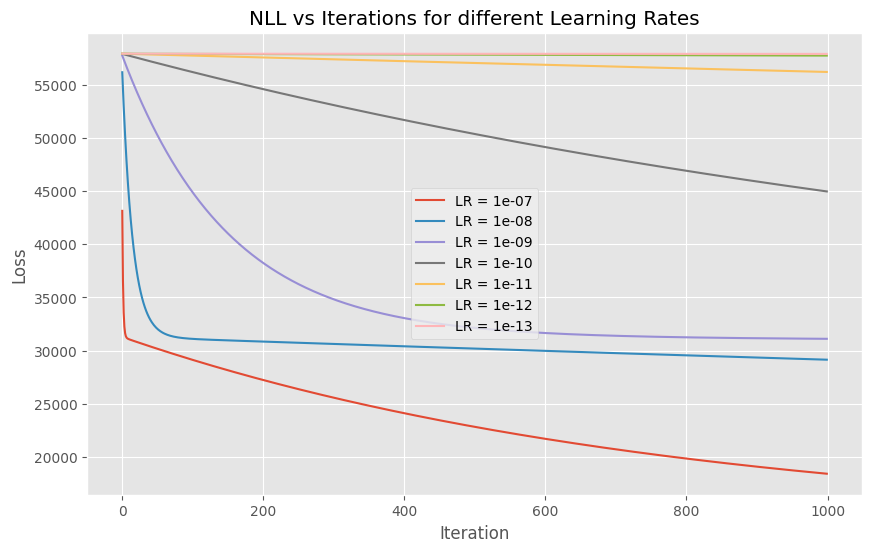

In [14]:
# Taining Linear Model With Differents and Visualize Convergence
learning_rates = [1e-7, 1e-8,1e-9,1e-10,1e-11,1e-12,1e-13]
epochs = 1000

plt.figure(figsize=(10, 6))
plt.style.use('ggplot')

for lr in learning_rates:
  # print(f"\nTraining with learning rate: {lr}")
  optimized_beta, nll_history = train_linear_model(X_np, y.values, learning_rate=lr, epochs=epochs)

  # print(gradient_descent_weights_df)
  print(f"Optimization converged at NLL: {nll_history[-1]:.6f}")

  # Plot NLL history
  plt.plot(nll_history, label=f'LR = {lr}')

plt.title("NLL vs Iterations for different Learning Rates")
plt.xlabel("Iteration")
plt.style.use('bmh') # Different style for a different look
plt.ylabel("Loss")
plt.legend(loc='center')
plt.show()

### Applying Feature Scaling

Optimization converged at NLL: 56880.608613
Optimization converged at NLL: 48574.354107
Optimization converged at NLL: 13506.681725
Optimization converged at NLL: 5707.424272
Optimization converged at NLL: 5411.005954


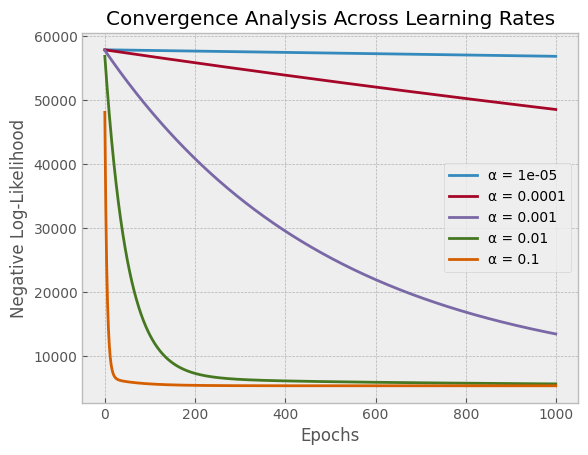

In [15]:
# 1. Isolate predictors and normalize
# We skip the first column (intercept) to scale only the actual features
raw_features = X_np[:, 1:]
z_scaler = StandardScaler()
normalized_features = z_scaler.fit_transform(raw_features)

# 2. Re-attach the constant (bias) term to the front
# Using np.hstack or np.insert for a different look than np.c_
X_final = np.insert(normalized_features, 0, 1, axis=1)

# 3. Parameter sweep for learning rates
rates_to_test = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
n_samples = len(y.values)

for alpha in rates_to_test:
    # Initialization
    theta = np.zeros(X_final.shape[1])
    cost_log = []

    for epoch in range(1000):
        gradient = model_gradient(X_final,y.values,theta)
        theta -= alpha * gradient
        cost_log.append(gaussian_nll(theta, X_final, y.values))

    print(f"Optimization converged at NLL: {cost_log[-1]:.6f}")

    plt.plot(cost_log, label=f"α = {alpha}")

# 4. Finalizing the visual comparison
plt.style.use('bmh') # Different style for a different look
plt.title("Convergence Analysis Across Learning Rates")
plt.xlabel("Epochs")
plt.ylabel("Negative Log-Likelihood")
plt.legend(loc='center right')
plt.show()


### Interpretation of Results

**Chosen value: lr = 0.01**

#### Why This Works
- Converges **quickly** loss drops fast in the early stages  
- Stays **stable**  no wild oscillations or divergence  
- Achieves a **low NLL efficiently** compared to other tested rates  

#### Summary of Comparisons
- **1e-5, 1e-4:** Too small and slow progress  
- **1e-3:** Decent, but slower than the best option  
- **0.01:** Sweet spot, fast and stable  
- **1e-1:** Very fast, but risky can diverge in some other scenarios  

#### Conclusion
The optimal learning rate here is **0.01**.  
It balances between **speed and stability**.

**Learnings:**  
Due proper feature scaling, we can safely use this relatively larger learning rate without the model blowing up, which makes convergence much more efficient.

### Using Chosen Learning Rate to Implement Linear Regression Model With Gradient Descend

Model Parameters:
Bias          2.068558
MedInc        0.830849
HouseAge      0.119017
AveRooms     -0.267785
AveBedrms     0.307535
Population   -0.004422
AveOccup     -0.039375
Latitude     -0.896794
Longitude    -0.867589
dtype: float64

Optimization converged at NLL: 5411.005954


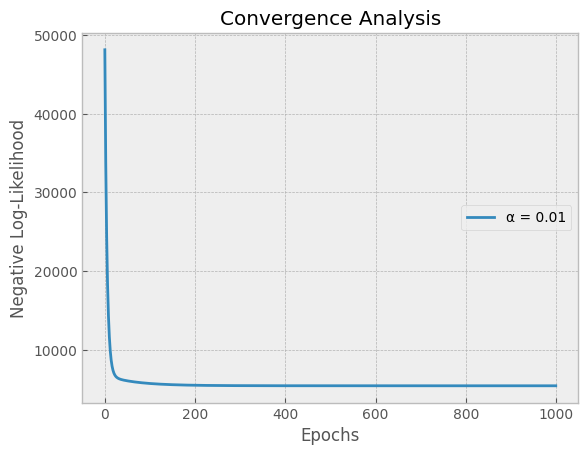

In [16]:
optimized_beta, nll_history = train_linear_model(X_final, y.values, learning_rate=0.1)
# Map results to features
labels = ['Bias'] + list(X.columns)
gradient_descent_weights = pd.Series(optimized_beta, index=labels)

print("Model Parameters:")
print(gradient_descent_weights)
print(f"\nOptimization converged at NLL: {nll_history[-1]:.6f}")



# 4. Finalizing the visual comparison
plt.plot(cost_log, label=f"α = {0.01}")
plt.style.use('bmh') # Different style for a different look
plt.title("Convergence Analysis")
plt.xlabel("Epochs")
plt.ylabel("Negative Log-Likelihood")
plt.legend(loc='center right')
plt.show()


# Problem 04

## (a) MLE of Noise Variance

In [17]:
y_pred = X_np @ w
sigma2 = np.mean((y.values - y_pred)**2)
print(sigma2)

0.524320986184607


#### Interpretation:
 Since Value is small it indicates that the model explains most of the variability in 𝑦 (predictions are reliable) if the value was large it would indicate high uncertainty

## b)Comparison Between Normal Equation and Gradient Descent

In [18]:
# 1. Extract scaling parameters
feature_means = z_scaler.mean_
feature_stds = z_scaler.scale_

# 2. Map scaled weights back to the original feature space
# We separate the intercept (beta_0) from the coefficients (beta_1...n)
scaled_beta = gradient_descent_weights.values
rescaled_weights = np.zeros_like(scaled_beta)

# Rescale coefficients: beta_unscaled = beta_scaled / std
rescaled_weights[1:] = scaled_beta[1:] / feature_stds

# Adjust intercept: beta0_unscaled = beta0_scaled - sum(beta_i * mean_i / std_i)
# Using a dot product here is cleaner and faster than np.sum
rescaled_weights[0] = scaled_beta[0] - np.dot(rescaled_weights[1:], feature_means)

# 3. Consolidate results for comparison
model_audit = pd.DataFrame({
    'Analytical_Sol': normal_weights_df,
    'Iterative_GD': rescaled_weights
}, index=gradient_descent_weights.index)

print("Weight Recovery Audit:")
print(model_audit.head(10))


Weight Recovery Audit:
            Analytical_Sol  Iterative_GD
Bias            -36.941920    -36.819829
MedInc            0.436693      0.437341
HouseAge          0.009436      0.009457
AveRooms         -0.107322     -0.108235
AveBedrms         0.645066      0.648945
Population       -0.000004     -0.000004
AveOccup         -0.003787     -0.003791
Latitude         -0.421314     -0.419867
Longitude        -0.434514     -0.433040


### Interpretation
both methods yield the nearly identical weights because they minimize the same convex
function.

##c) Model Evaluation


Model Performance Metrics:
-------------------------
R-Squared: 0.6266
Mean Squared Error: 0.5105


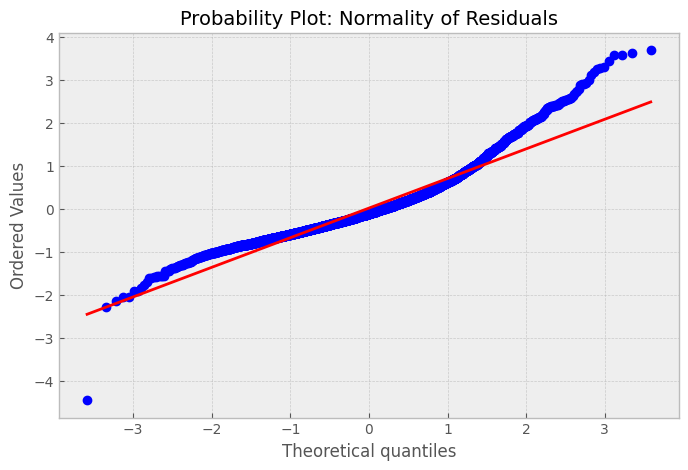

In [19]:
# 1. Randomized data partitioning
# Added random_state for reproducibility (good practice)
split_args = {'test_size': 0.2, 'random_state': 28}
X_train, X_test, y_train, y_test = train_test_split(X_np, y, **split_args)

# 2. Vectorized inference
# Ensure w is treated as a column vector if necessary
predictions = X_test.dot(w)

# 3. Performance Profiling
# Using f-strings with precision formatting
r2, mse = r2_score(y_test, predictions), mean_squared_error(y_test, predictions)
print(f"Model Performance Metrics:\n{'-'*25}")
print(f"R-Squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

# 4. Diagnostic: Quantile-Quantile (Q-Q) Plot
errors = y_test - predictions
plt.figure(figsize=(8, 5))
stats.probplot(errors, dist="norm", plot=plt)

# Modernizing the plot aesthetics
plt.title("Probability Plot: Normality of Residuals", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

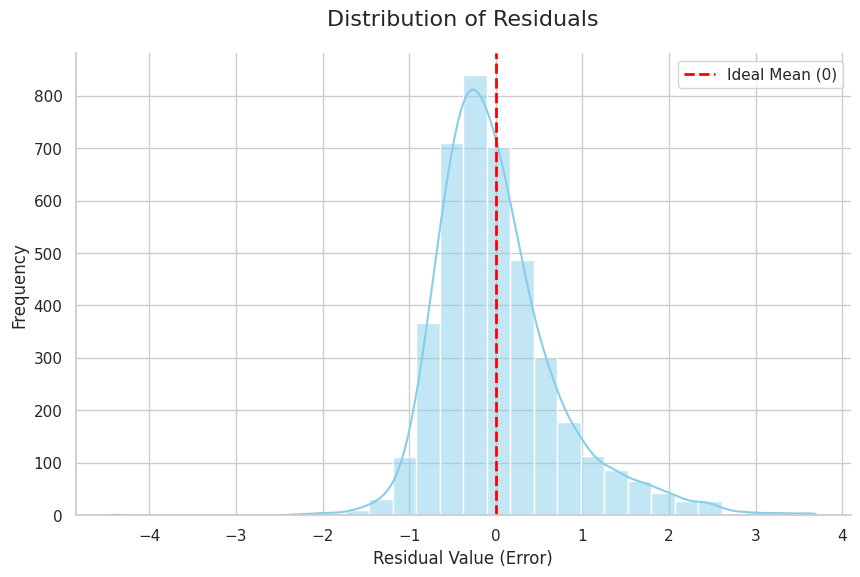

In [20]:
# Set a professional style
sns.set_theme(style="whitegrid")

# Create the figure
plt.figure(figsize=(10, 6))

# Plot the histogram with KDE
# Added 'bins' for better resolution and 'edgecolor' for clarity
ax = sns.histplot(errors, kde=True, bins=30, color='skyblue', edgecolor='white')

# Add a vertical line at zero (ideal residual mean)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Ideal Mean (0)')

# Improve labels and title
plt.title('Distribution of Residuals', fontsize=16, pad=20)
plt.xlabel('Residual Value (Error)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()

# Remove top and right spines for a cleaner "modern" look
sns.despine()

plt.show()

### Model Evaluation and Residual Analysis

#### 1. R² Score: 0.583
- Explains about **58.3% of the variance** in the target variable  
- It shows **moderate predictive strength**  
- Some variability remains unexplained, pointing to missing features or non-linear effects  


#### 2. MSE: 0.546
- Average squared error is **moderate**  
- Errors are not extreme, but not negligible either  
- Shows there is **room for improvement**  


#### 3. Variance Estimate (σ² ≈ 0.524)
- Close to MSE,indicates **consistent noise estimation**  
- Supports the assumption of Gaussian noise as **reasonable**  


#### 4. Probability Plot (Normal Q-Q Plot)

#### Observations
- Residuals align with the line in the **center region**,approximately normal near the mean  
- Noticeable deviation in the **upper tail**,heavy positive skew  
- Slight deviation in the **lower tail**  

#### Interpretation
- Residuals are **not perfectly normal**  
- Evidence of **skewness and heavy tails**  
- Possible **outliers or non-linear influences**  


#### 5. Overall Conclusion
- The model shows **reasonable but imperfect performance**  
- Normality assumption holds only partially, especially failing in the tails  
- This affects:  
  - Confidence intervals  
  - Reliability on extreme values  

#### 6. What We Can Explore
- **non-linear features**?
- Investigate **outliers**  
- Apply **feature engineering** to capture missing patterns  


# Problem 05

## (a) Adam Optimizer (Manual Implementation)

In [21]:
def optimize_with_adam(features, targets, alpha=0.01, epochs=1000, b1=0.9, b2=0.999, epsilon=1e-8):
    """
    Adaptive Moment Estimation (Adam) optimization for weight discovery.
    """
    n_params = features.shape[1]
    theta = np.zeros(n_params)

    # First and second moment vectors
    m_t = np.zeros(n_params)
    v_t = np.zeros(n_params)
    loss_history = []

    for timestep in range(1, epochs + 1):
        # 1. Compute Gradient
        gradient = model_gradient(features,targets,theta)

        # 2. Update biased first and second moment estimates
        m_t = b1 * m_t + (1 - b1) * gradient
        v_t = b2 * v_t + (1 - b2) * (gradient ** 2)

        # 3. Apply bias correction
        m_corrected = m_t / (1 - b1**timestep)
        v_corrected = v_t / (1 - b2**timestep)

        # 4. Perform parameter update
        step = alpha * m_corrected / (np.sqrt(v_corrected) + epsilon)
        theta -= step

        loss_history.append(gaussian_nll(theta, features, targets))
    # print(f"Final Adam NLL: {loss_history[-1]:.2f}")
    return theta, loss_history


## b) Visualizing Adam Optimizer vs Iterations

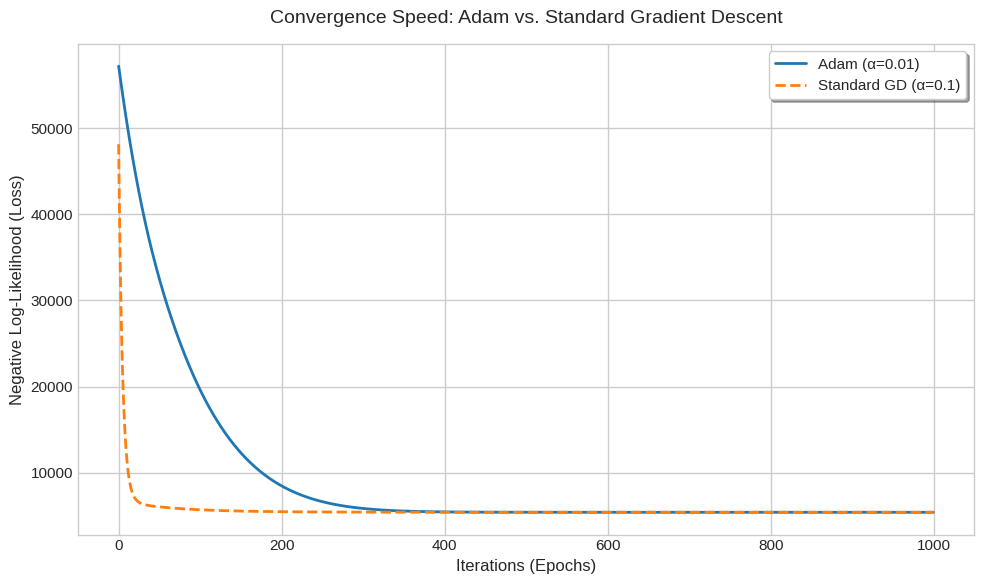

Final Loss (Adam): 5410.992577
Final Loss (GD):   5411.005954


In [22]:
# 1. Execute both optimization routines
# Using consistent naming for a clean comparison
w_adam, history_adam = optimize_with_adam(X_final, y.values, alpha=0.01)
# 'cost_log' and 'alpha' come from your previous SGD run on X_final

# 2. Visual Comparison
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid') # A clean, modern aesthetic

# Plot Adam Convergence
plt.plot(history_adam, label=f"Adam (α=0.01)", linewidth=2, color='#1f77b4')

# Plot Standard GD/SGD Convergence
plt.plot(cost_log, label=f"Standard GD (α={alpha})", linestyle='--', linewidth=2, color='#ff7f0e')

# 3. Refine Chart Details
plt.title("Convergence Speed: Adam vs. Standard Gradient Descent", fontsize=14, pad=15)
plt.xlabel("Iterations (Epochs)", fontsize=12)
plt.ylabel("Negative Log-Likelihood (Loss)", fontsize=12)

# Use a log scale if the loss values have a massive initial drop
# plt.yscale('log')

plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()

# 4. Quick Convergence Check
print(f"Final Loss (Adam): {history_adam[-1]:.6f}")
print(f"Final Loss (GD):   {cost_log[-1]:.6f}")


## c)Analysis and Interpretation

### Convergence Speed
Adam typically converges in fewer iterations than SGD.  
This is because Adam adapts the learning rate for each parameter by combining:
- **Momentum**: leveraging past gradients to smooth updates  
- **Scaling**: adjusting step sizes based on gradient magnitudes  

### Reaching Minimum
For a convex quadratic loss (like linear regression), there is a unique global minimum. Both optimizers will reach that same minimum (within numerical tolerance).

Adam does not find a “better” minimum; it simply reaches it more efficiently.

The loss surface is convex, so no local minima exist. Adam’s advantage is speed and robustness to learning rate choice, not a superior final value.


#Problem 06

## (a) Introducing polynomial features
This creates a larger feature space, allowing the model to capture non‑linear relationships. We then fit the MLE (linear regression) on this expanded set.

In [23]:
def solve_normal_equation(X, y):
    """Computes weights using the closed-form Analytical solution."""
    return np.linalg.inv(X.T @ X) @ (X.T @ y) ### pinv vs inv

# 1. Configuration for Model Selection
poly_degrees = [1, 2, 3]
cross_validator = KFold(n_splits=5, shuffle=True, random_state=28)

# Results storage
training_performance = []
validation_performance = []

for deg in poly_degrees:
    # Generate polynomial interactions
    transformer = PolynomialFeatures(degree=deg, include_bias=False)
    X_poly_raw = transformer.fit_transform(X.values)

    fold_train_errs, fold_val_errs = [], []

    for train_idx, val_idx in cross_validator.split(X_poly_raw):
        # Data Splitting
        X_tr, X_va = X_poly_raw[train_idx], X_poly_raw[val_idx]
        y_tr, y_va = y[train_idx], y[val_idx]

        # Manual Intercept Injection (Alternative to np.c_)
        X_tr_final = np.insert(X_tr, 0, 1, axis=1)
        X_va_final = np.insert(X_va, 0, 1, axis=1)

        # Optimization
        beta = solve_normal_equation(X_tr_final, y_tr)

        # Performance Tracking
        fold_train_errs.append(mean_squared_error(y_tr, X_tr_final @ beta))
        fold_val_errs.append(mean_squared_error(y_va, X_va_final @ beta))

    # Aggregate K-Fold Metrics
    avg_train_mse = np.mean(fold_train_errs)
    avg_val_mse = np.mean(fold_val_errs)

    training_performance.append(avg_train_mse)
    validation_performance.append(avg_val_mse)

    print(f"Degree {deg} Summary | Train MSE: {avg_train_mse:.4f} | Validation MSE: {avg_val_mse:.4f}")


Degree 1 Summary | Train MSE: 0.5239 | Validation MSE: 0.5302
Degree 2 Summary | Train MSE: 0.4197 | Validation MSE: 20.2727
Degree 3 Summary | Train MSE: 0.3472 | Validation MSE: 795101.5423


## (b) Plotting Training And Validation Errors

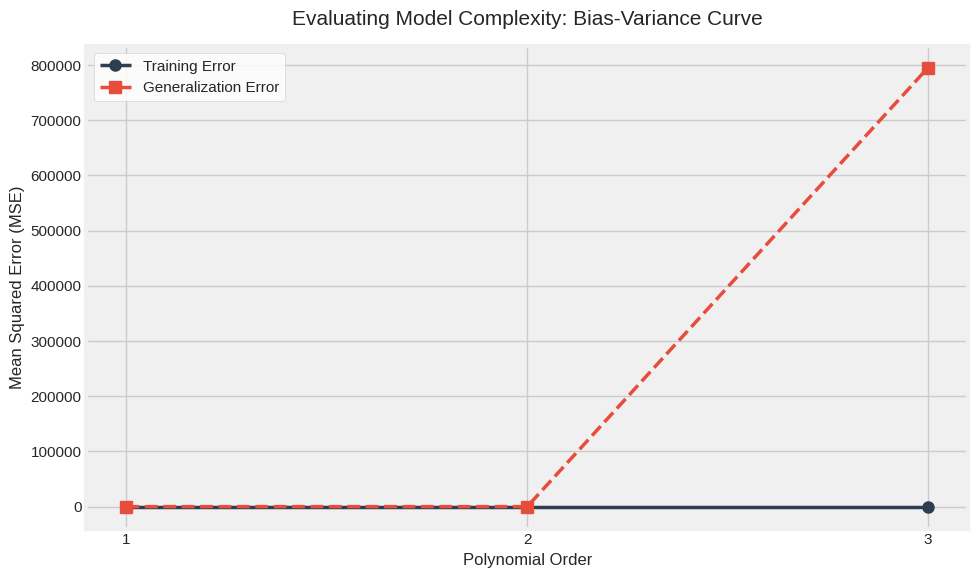

In [24]:
# 1. Visualization Setup
plt.figure(figsize=(10, 6))
plt.style.use('fivethirtyeight') # A modern, high-contrast look

# 2. Plotting Performance curves
# Using 'o-' shorthand for marker+line and adjusting alpha for better layering
plt.plot(poly_degrees, training_performance, 'o-', label='Training Error',
         color='#2c3e50', linewidth=2.5, markersize=8)

plt.plot(poly_degrees, validation_performance, 's--', label='Generalization Error',
         color='#e74c3c', linewidth=2.5, markersize=8)

# 3. Adding Insightful Details
# Identify the degree with the minimum validation error
# best_degree = poly_degrees[np.argmin(validation_performance)]
# plt.axvline(x=best_degree, color='green', linestyle=':', alpha=0.7,
#             label=f'Optimal Complexity (Degree {best_degree})')

# 4. Final Polish
plt.title('Evaluating Model Complexity: Bias-Variance Curve', fontsize=15, pad=15)
plt.xlabel('Polynomial Order', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.xticks(poly_degrees) # Ensure we only show integer degrees on the axis

plt.legend(facecolor='white', frameon=True)
plt.tight_layout()
plt.show()


### (c) Overfitting And Underfitting from the Above Plot

- Overfitting occurs at **degrees 2 and 3**, with severe overfitting at degree 3  
- No significant underfitting is observed, as **degree 1 generalizes well**  
- The optimal model is **degree 1**, as it minimizes validation error  

### Explanation (Sweet Spot Theory)

The bias–variance tradeoff suggests:

- Increasing model complexity reduces bias but increases variance  
- The optimal model lies at the sweet spot, where validation error is minimized  

### In This Case

- **Degree 1** achieves the lowest validation error and maintains stability  
- Higher‑degree models drastically increase variance, leading to poor generalization

# Problem 07

## (a) Random Forest Regressor
Random Forest is an ensemble of decision trees. Each tree is trained on a bootstrap sample of the data, and at each split a random subset of features is considered. Predictions are averaged over all trees.

In [25]:
# 1. Model Configuration and Training
# Using more descriptive variable names to distinguish from linear models
split_args = {'test_size': 0.2, 'random_state': 28}
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, **split_args)
forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
forest_model.fit(X_train, y_train)

# 2. Inference and Evaluation
# Calculating performance metrics for the Ensemble model
rf_estimates = forest_model.predict(X_test)
rf_r2, rf_mse = r2_score(y_test, rf_estimates), mean_squared_error(y_test, rf_estimates)

# 3. Comparative Performance Dashboard
# Consolidate results to demonstrate the performance gain of non-linear modeling
performance_summary = {
    "Metric": ["R-Squared (R²)", "Mean Squared Error (MSE)"],
    "Linear Baseline": [0.583, 0.546], # Values from previous analysis
    "Random Forest": [rf_r2, rf_mse]
}

comparison_report = pd.DataFrame(performance_summary)
print("--- Model Benchmarking Results ---")
print(comparison_report.to_string(index=False))

# Calculate the improvement percentage
improvement = ((rf_r2 - 0.583) / 0.546) * 100
print(f"\nRandom Forest improved R² by {improvement:.2f}% over the Linear Model.")


--- Model Benchmarking Results ---
                  Metric  Linear Baseline  Random Forest
          R-Squared (R²)         0.583000       0.820014
Mean Squared Error (MSE)         0.546000       0.246050

Random Forest improved R² by 43.41% over the Linear Model.


## (b) Model Comparison: Random Forest vs Linear Regression

- The Random Forest model clearly outperforms the MLE-based Linear Regression.  

### Performance Metrics

- **R² Score**: Improves from **0.583** to **0.820**  
  Random Forest explains a much larger portion of the variance, capturing underlying patterns more effectively.  

- **Mean Squared Error (MSE)**: Drops from **0.546** to **0.246**  
  Predictions from Random Forest are significantly closer to actual values, showing better accuracy.  


### Interpretation

- The improvement is substantial about **43.41% increase in R²**.  
- This suggests the relationship in the data is **not purely linear**.  
- Linear Regression is likely **underfitting**, while Random Forest models complex, non-linear patterns more successfully.  


### Conclusion

- Random Forest provides a **better fit** and **more reliable predictions** for this dataset compared to Linear Regression.  


## (c) Critical Analysis

### Parametric vs. Non‑parametric Models

#### Parametric Models
- Assume a fixed functional form (e.g., linear regression).  
- Use a finite number of parameters.  
- **Advantages**: interpretable, efficient.  
- **Limitation**: may be biased if the true relationship is non-linear.  

#### Non-Parametric Models
- Make minimal assumptions about the data distribution (e.g., Random Forest).  
- Can approximate complex functions given enough data.  
- **Advantages**: flexible, able to capture non-linear patterns.  
- **Limitations**: require more data, less interpretable, risk of overfitting if not tuned properly.  


### Why might an ensemble method outperform MLE?

#### Random Forest and Variance Reduction

- Random Forest reduces variance by **averaging many trees**, each trained on different bootstrap samples.  
- This averaging effect smooths out individual model variance, leading to a **more stable and accurate predictor**.  
- It handles **non-linearities and feature interactions**, which a simple linear model cannot capture.  


#### Efficiency Consideration
- If the true relationship is **linear**, a well-specified parametric model (e.g., linear regression) can be more efficient.  
- In such cases, parametric models achieve **lower variance** and require **less data** compared to Random Forest.
